In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from loguru import logger


#1. 构建子图
#1.1 声明子图的状态
class OverAllState(TypedDict):
    raw_text:str #未清洗的文本
    stripped_text:str # 去除首尾的空格
    punctuated_text:str # 句尾添加句号

#1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state:OverAllState) -> OverAllState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text":stripped_text
    }

#1.3 添加句号的节点
def subgraph_punctuated_node(state:OverAllState) -> OverAllState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text":punctuated_text
    }

#1.4 构建子图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_strip_node",subgraph_strip_node)
builder.add_node("subgraph_punctuated_node",subgraph_punctuated_node)
builder.add_edge(START,"subgraph_strip_node")
builder.add_edge("subgraph_strip_node","subgraph_punctuated_node")
builder.add_edge("subgraph_punctuated_node",END)
subgraph = builder.compile()

res = subgraph.invoke({
    "raw_text":"   langgraph真有意思   "
})
print(res)


2026-08-15 16:10:01.784 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-08-15 16:10:01.785 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'raw_text': '   langgraph真有意思   ', 'stripped_text': 'langgraph真有意思', 'punctuated_text': 'langgraph真有意思。'}


In [2]:
parent_builder = StateGraph(state_schema=OverAllState)
parent_builder.add_node("subgraph_node",subgraph)
parent_builder.add_edge(START,"subgraph_node")
parent_builder.add_edge("subgraph_node",END)

parent_graph = parent_builder.compile()

res = parent_graph.invoke({ "raw_text":"   langgraph真有意思   "})
print(res)


2026-08-15 16:10:03.997 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-08-15 16:10:03.998 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'raw_text': '   langgraph真有意思   ', 'stripped_text': 'langgraph真有意思', 'punctuated_text': 'langgraph真有意思。'}


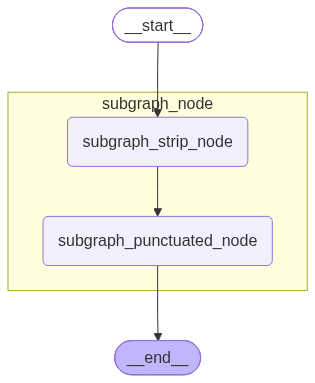

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ --> subgraph_node\3asubgraph_strip_node;
	subgraph_node\3asubgraph_punctuated_node --> __end__;
	subgraph subgraph_node
	subgraph_node\3asubgraph_strip_node(subgraph_strip_node)
	subgraph_node\3asubgraph_punctuated_node(subgraph_punctuated_node)
	subgraph_node\3asubgraph_strip_node --> subgraph_node\3asubgraph_punctuated_node;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from IPython.display import display,Image
display(
    Image(
        parent_graph.get_graph(xray=True).draw_mermaid_png()
    )
)

raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)

In [4]:
list(parent_graph.get_subgraphs())

[('subgraph_node',
  <langgraph.graph.state.CompiledStateGraph at 0x2081d926270>)]